In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [2]:
wine = load_wine()

In [3]:
df = pd.DataFrame(wine.data, columns = wine.feature_names)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [4]:
# add target(output) column
df['wine_type'] = wine.target # the target values must be stored in wine_type
#Wine_Type → the name you choose for the new column
#wine.target → the values that will go into that column

In [5]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_type
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [6]:
df.shape

(178, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_

In [8]:
x = wine.data
y = wine.target

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

To find the best value of K

In [14]:
k_values = range(1,15)
cv_score = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    scores = cross_val_score(knn,x_scaled, y , cv = 5)
    cv_score.append(scores.mean())

Here we are trying to find the k value with cross validation. Cross Validation is done by splitting the x_scaled, y into 5 folds and then each iteration is then divided into 4 folds(train), 1 fold(test). The process is repeated fpor 5 times. Finally 5 test scores are averaged to get the cross validation score for that k value.

In [16]:
result = pd.DataFrame({'k_values': k_values, 'Mean CV Accuracy': cv_score})
print('Cross Validation Scores For Different K values\n', result)

Cross Validation Scores For Different K values
     k_values  Mean CV Accuracy
0          1          0.949524
1          2          0.938413
2          3          0.943968
3          4          0.938413
4          5          0.955079
5          6          0.949524
6          7          0.966508
7          8          0.966508
8          9          0.949683
9         10          0.955238
10        11          0.955238
11        12          0.955238
12        13          0.955238
13        14          0.955238


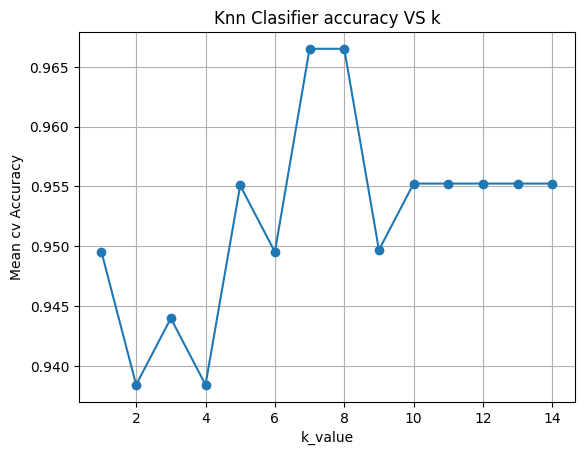

In [17]:
# Visulaizing the same value
import matplotlib.pyplot as plt
plt.plot(k_values, cv_score, marker = 'o')
plt.title('Knn Clasifier accuracy VS k')
plt.xlabel('k_value')
plt.ylabel('Mean cv Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Finding Best K
best_k = k_values[np.argmax(cv_score)] # argmax - position of the index that has the max cv_score.
print(f'best k value:{best_k}')
print(f'Highest mean cv accuracy: {max(cv_score):.3f}') # :.3f - round of to 3 place

best k value:7
Highest mean cv accuracy: 0.967


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.3, random_state = 42)

In [28]:
knn = KNeighborsClassifier(n_neighbors = 7) # n_neighbor = k_value

In [29]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

Or method
finalknn = KNeighborsClassifier(n_neighbors = int(best_k['k_value']))
finalknn.fit(x_train, y_train)


In [30]:
y_pred = knn.predict(x_test)

In [32]:
print('Accuracy Score', accuracy_score(y_test, y_pred))
print('Classification Report', classification_report(y_test, y_pred))

Accuracy Score 0.9629629629629629
Classification Report               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



In [ ]:
#predictiong on the test data
sample = x_scaled[10].reshape(1, -1) # we are predictiong on the test data- 10 indes(ie, 11th row) so here we aere geeting the 11th row and then reshapeing it into 2 d using reshape(1,-1)
#here there are 13 columns so it is reahaped to 1 row and 13 columns
pred = knn.predict(sample)
print('Predicted Wine Type:', wine.target_names[pred][0]) # actual target name(which class)
print(pred[0])

Predicted Wine Type: class_0
0
